## 1️⃣ Import Required Libraries

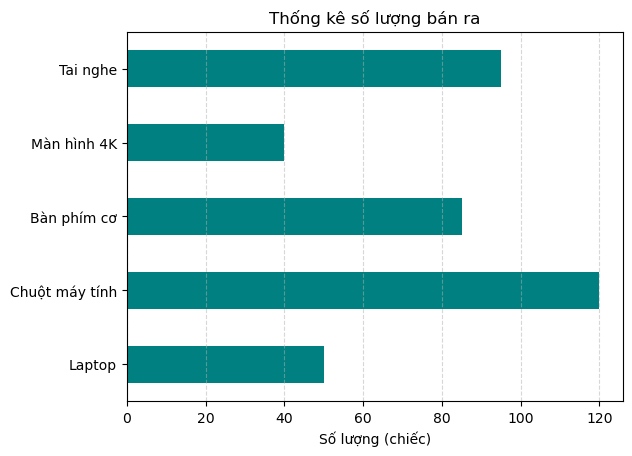

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tạo dữ liệu mẫu
data = {
    'Sản phẩm': ['Laptop', 'Chuột máy tính', 'Bàn phím cơ', 'Màn hình 4K', 'Tai nghe'],
    'Số lượng bán': [50, 120, 85, 40, 95]
}

# 2. Chuyển thành DataFrame
df = pd.DataFrame(data)

# Đặt cột 'Sản phẩm' làm chỉ mục (index) để nó hiện lên trục đứng
df = df.set_index('Sản phẩm')

# 3. Vẽ biểu đồ
# kind='barh' sẽ tạo biểu đồ thanh ngang
df.plot(kind='barh', color='teal', legend=False)

# 4. Trang trí thêm (Tuỳ chọn)
plt.title('Thống kê số lượng bán ra')
plt.xlabel('Số lượng (chiếc)')
plt.ylabel('') # Bỏ nhãn trục Y cho gọn
plt.grid(axis='x', linestyle='--', alpha=0.5) # Thêm lưới mờ để dễ nhìn

# 5. Hiển thị
plt.show()

In [26]:
import json
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
from collections import defaultdict
import time
from datetime import datetime

# Data & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mem0
from mem0 import Memory

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load environment
load_dotenv()

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Configure API Keys and Models

In [27]:
# Check Groq API Key
api_key = os.getenv("GROQ_API_KEY")
if api_key:
    print(f"✅ GROQ_API_KEY found: {api_key[:20]}...")
else:
    print("❌ GROQ_API_KEY not found in .env")
    print("Please add: GROQ_API_KEY=your_key_here to .env file")

# Configuration
CONFIG = {
    "llm_provider": "groq",
    "llm_model": "llama-3.1-8b-instant",
    "embedder_provider": "huggingface",
    "embedder_model": "sentence-transformers/all-mpnet-base-v2",
    "embedding_dims": 768,
    "vector_store_provider": "qdrant",
    "collection_name": "mem0_eval",
    "data_path": "./mem0_eval_data",
    "history_path": "./mem0_eval_history",
    "dataset_path": "./dataset/locomo10.json",
}

print("\n📋 Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

✅ GROQ_API_KEY found: gsk_Pc15eZDnAcOvZLGE...

📋 Configuration:
  llm_provider: groq
  llm_model: llama-3.1-8b-instant
  embedder_provider: huggingface
  embedder_model: sentence-transformers/all-mpnet-base-v2
  embedding_dims: 768
  vector_store_provider: qdrant
  collection_name: mem0_eval
  data_path: ./mem0_eval_data
  history_path: ./mem0_eval_history
  dataset_path: ./dataset/locomo10.json


## 3️⃣ Define Memory Configuration Function

In [32]:
def get_mem0_config(collection_name="mem0_eval"):
    """
    Get Mem0 configuration with Groq LLM + HuggingFace embeddings
    Using QdrantClient directly for in-memory operation
    """
    from qdrant_client import QdrantClient
    
    # Create in-memory Qdrant client
    qdrant_client = QdrantClient(":memory:")
    
    return {
        "llm": {
            "provider": "groq",
            "config": {
                "model": "llama-3.1-8b-instant",
                "temperature": 0.7,
                "max_tokens": 8000,
            }
        },
        "embedder": {
            "provider": "huggingface",
            "config": {
                "model": "sentence-transformers/all-mpnet-base-v2",
            }
        },
        "vector_store": {
            "provider": "qdrant",
            "config": {
                "collection_name": collection_name,
                "client": qdrant_client,  # Pass the client directly
                "embedding_model_dims": 768,  # 🔴 CRITICAL!
            }
        },
        "history_db_path": "./mem0_eval_history",
    }

print("✅ Memory configuration function defined (using in-memory Qdrant client)")

✅ Memory configuration function defined (using in-memory Qdrant client)


## 🔍 Debug: Inspect Dataset Structure


In [24]:
# Debug: Load and inspect first sample
import json
with open(CONFIG["dataset_path"], 'r', encoding='utf-8') as f:
    sample = json.load(f)[0]

print("="*70)
print("🔍 DATASET STRUCTURE INSPECTION")
print("="*70)

# Check top-level keys
print(f"\n📋 Top-level keys: {list(sample.keys())}")

# Check session_summary structure
if 'session_summary' in sample:
    summaries = sample['session_summary']
    print(f"\n📝 session_summary structure:")
    print(f"   Type: {type(summaries)}")
    print(f"   Keys (first 5): {list(summaries.keys())[:5]}")
    
    # Check if summaries are strings or dicts
    first_summary_key = list(summaries.keys())[0]
    first_summary = summaries[first_summary_key]
    print(f"   First summary type: {type(first_summary)}")
    print(f"   First summary (first 100 chars): {str(first_summary)[:100]}")

# Check QA pairs
if 'qa' in sample:
    qa_pairs = sample['qa']
    print(f"\n❓ QA pairs:")
    print(f"   Total pairs: {len(qa_pairs)}")
    if qa_pairs:
        first_qa = qa_pairs[0]
        print(f"   First QA type: {type(first_qa)}")
        print(f"   First QA keys: {list(first_qa.keys())}")
        print(f"   Question: {first_qa.get('question', '')[:80]}")
        print(f"   Answer: {first_qa.get('answer', '')}")

# Check conversation
if 'conversation' in sample:
    conv = sample['conversation']
    print(f"\n💬 Conversation structure:")
    print(f"   Type: {type(conv)}")
    print(f"   Keys (first 5): {list(conv.keys())[:5]}")
    if conv:
        first_session = list(conv.values())[0]
        print(f"   First session type: {type(first_session)}")
        if isinstance(first_session, list) and first_session:
            print(f"   First turn in session: {first_session[0]}")

print("\n" + "="*70)


🔍 DATASET STRUCTURE INSPECTION

📋 Top-level keys: ['qa', 'conversation', 'event_summary', 'observation', 'session_summary', 'sample_id']

📝 session_summary structure:
   Type: <class 'dict'>
   Keys (first 5): ['session_1_summary', 'session_2_summary', 'session_3_summary', 'session_4_summary', 'session_5_summary']
   First summary type: <class 'str'>
   First summary (first 100 chars): Caroline and Melanie had a conversation on 8 May 2023 at 1:56 pm. Caroline mentioned that she attend

❓ QA pairs:
   Total pairs: 199
   First QA type: <class 'dict'>
   First QA keys: ['question', 'answer', 'evidence', 'category']
   Question: When did Caroline go to the LGBTQ support group?
   Answer: 7 May 2023

💬 Conversation structure:
   Type: <class 'dict'>
   Keys (first 5): ['speaker_a', 'speaker_b', 'session_1_date_time', 'session_1', 'session_2_date_time']
   First session type: <class 'str'>



In [25]:
# Check a few QA pairs and their answers
print("="*70)
print("🎯 Sample QA Pairs to Match")
print("="*70)

for i, qa in enumerate(sample['qa'][:3]):
    question = qa.get('question', '')
    answer = qa.get('answer', '')
    print(f"\nQA #{i+1}:")
    print(f"  Q: {question}")
    print(f"  A: {answer}")
    print(f"  A type: {type(answer)}")

# Check what session summaries contain
print("\n" + "="*70)
print("📚 Sample Session Summaries")
print("="*70)

summaries = sample['session_summary']
for key in list(summaries.keys())[:3]:
    print(f"\n{key}:")
    print(f"  {summaries[key][:150]}...")


🎯 Sample QA Pairs to Match

QA #1:
  Q: When did Caroline go to the LGBTQ support group?
  A: 7 May 2023
  A type: <class 'str'>

QA #2:
  Q: When did Melanie paint a sunrise?
  A: 2022
  A type: <class 'int'>

QA #3:
  Q: What fields would Caroline be likely to pursue in her educaton?
  A: Psychology, counseling certification
  A type: <class 'str'>

📚 Sample Session Summaries

session_1_summary:
  Caroline and Melanie had a conversation on 8 May 2023 at 1:56 pm. Caroline mentioned that she attended an LGBTQ support group and was inspired by the ...

session_2_summary:
  On May 25, 2023 at 1:14 pm, Melanie tells Caroline about her recent experience running a charity race for mental health. Caroline expresses pride and ...

session_3_summary:
  Caroline and Melanie had a conversation at 7:55 pm on 9 June, 2023. Caroline shared about her school event last week where she talked about her transg...


## Debug: Test Memory Add & Search


In [38]:
# Test if memory.add() and memory.search() are working with correct API
print("="*70)
print("🧪 TEST: Memory Add & Search Functionality (with correct API)")
print("="*70)

user_id = "test_user"

# Test 1: Add a simple fact
test_fact = "Caroline attended an LGBTQ support group on 7 May 2023"
print(f"\nTest 1: Adding fact: {test_fact}")
try:
    result = memory.add(test_fact, user_id=user_id)
    print(f"✅ Memory.add() successful")
    print(f"   Result: {result}")
except Exception as e:
    print(f"❌ Memory.add() failed: {e}")

# Test 2: Search for the fact
test_question = "When did Caroline go to the LGBTQ support group?"
print(f"\nTest 2: Searching for: {test_question}")
try:
    result = memory.search(test_question, user_id=user_id, limit=2)
    print(f"✅ Memory.search() successful")
    results = result.get("results", []) if isinstance(result, dict) else []
    print(f"   Found {len(results)} results:")
    for i, item in enumerate(results):
        print(f"   Result {i+1}:")
        print(f"     Memory: {item.get('memory', '')[:100]}...")
        print(f"     Score: {item.get('score', 0)}")
except Exception as e:
    print(f"❌ Memory.search() failed: {e}")

# Test 3: Check matching logic
print(f"\nTest 3: Test answer matching")
from difflib import SequenceMatcher

def string_similarity(a, b):
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

expected_answer = "7 may 2023"
test_strings = [
    "Caroline attended an LGBTQ support group on 7 May 2023",
    "She went to the group on May 7th 2023",
    "different answer",
]

for test_str in test_strings:
    similarity = string_similarity(expected_answer, test_str.lower())
    match = expected_answer in test_str.lower()
    print(f"  '{test_str[:50]}...'")
    print(f"    Exact match: {match}, Similarity: {similarity:.2f}")

print("\n" + "="*70)


🧪 TEST: Memory Add & Search Functionality (with correct API)

Test 1: Adding fact: Caroline attended an LGBTQ support group on 7 May 2023
✅ Memory.add() successful
   Result: {'results': [{'id': '3f36e771-80e5-4393-82ec-31a5b70a353e', 'memory': 'Attended an LGBTQ support group on 7 May 2023', 'event': 'ADD'}]}

Test 2: Searching for: When did Caroline go to the LGBTQ support group?
✅ Memory.search() successful
   Found 1 results:
   Result 1:
     Memory: Attended an LGBTQ support group on 7 May 2023...
     Score: 0.5787452501967629

Test 3: Test answer matching
  'Caroline attended an LGBTQ support group on 7 May ...'
    Exact match: True, Similarity: 0.31
  'She went to the group on May 7th 2023...'
    Exact match: False, Similarity: 0.38
  'different answer...'
    Exact match: False, Similarity: 0.15

✅ Memory.add() successful
   Result: {'results': [{'id': '3f36e771-80e5-4393-82ec-31a5b70a353e', 'memory': 'Attended an LGBTQ support group on 7 May 2023', 'event': 'ADD'}]}

Test 

## 4️⃣ Load LOCOMO Dataset

In [29]:
def load_dataset(dataset_path, num_conversations=None):
    """
    Load LOCOMO dataset - actual structure has conversation sessions and QA pairs
    """
    with open(dataset_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    if num_conversations:
        data = data[:num_conversations]
    
    print(f"📊 Loaded {len(data)} conversation samples")
    
    # Show sample structure
    if data:
        print(f"\n📝 Sample LOCOMO structure:")
        sample = data[0]
        num_qa = len(sample.get('qa', []))
        num_sessions = len([k for k in sample.get('conversation', {}).keys() if k.startswith('session_')])
        print(f"  - QA Pairs: {num_qa}")
        print(f"  - Sessions: {num_sessions}")
        print(f"  - Sample Q: {sample['qa'][0]['question'][:60]}...")
        print(f"  - Sample A: {sample['qa'][0]['answer']}")
    
    return data

# Load dataset  
num_conv = 3  # Start with 3 full conversation samples
dataset = load_dataset(CONFIG["dataset_path"], num_conversations=num_conv)
print(f"\n✅ Dataset loaded successfully!")

📊 Loaded 3 conversation samples

📝 Sample LOCOMO structure:
  - QA Pairs: 199
  - Sessions: 54
  - Sample Q: When did Caroline go to the LGBTQ support group?...
  - Sample A: 7 May 2023

✅ Dataset loaded successfully!


## 5️⃣ Initialize Memory with Groq

In [ ]:
print("🚀 Initializing Memory with Groq...\n")

try:
    config = get_mem0_config()
    memory = Memory.from_config(config)
    print("✅ Memory initialized successfully!")
    print(f"   LLM: Groq - llama-3.1-8b-instant")
    print(f"   Embedder: HuggingFace - all-mpnet-base-v2 (768-dim)")
    print(f"   Vector Store: Qdrant (local)")
    print(f"   Status: Completely FREE ✨")
except Exception as e:
    print(f"❌ Error initializing Memory: {e}")
    import traceback
    traceback.print_exc()

🚀 Initializing Memory with Groq...

✅ Memory initialized successfully!
   LLM: Groq - llama-3.1-8b-instant
   Embedder: HuggingFace - all-mpnet-base-v2 (768-dim)
   Vector Store: Qdrant (local)
   Status: Completely FREE ✨
✅ Memory initialized successfully!
   LLM: Groq - llama-3.1-8b-instant
   Embedder: HuggingFace - all-mpnet-base-v2 (768-dim)
   Vector Store: Qdrant (local)
   Status: Completely FREE ✨


d:\Documents\HUST\2022-2026\20251\Project_III\mem0\mem0\vector_stores\qdrant.py:112: UserWarning: Payload indexes have no effect in the local Qdrant. Please use server Qdrant if you need payload indexes.
  self.client.create_payload_index(


## 6️⃣ Define Evaluation Functions

In [37]:
def calculate_accuracy(memory, sample_data, user_id="locomo_eval_user"):
    """
    Calculate accuracy for LOCOMO sample - IMPROVED VERSION
    - Use conversation sessions to add context to memory
    - Then answer QA pairs by searching memory with semantic similarity
    """
    qa_pairs = sample_data.get("qa", [])
    session_summaries = sample_data.get("session_summary", {})
    
    if not qa_pairs:
        return 0.0, [], 0
    
    # First, add all session summaries as memory context
    sessions_added = 0
    for session_key, summary in session_summaries.items():
        if summary and isinstance(summary, str) and len(summary) > 10:
            try:
                memory.add(f"Conversation context: {summary}", user_id=user_id)
                sessions_added += 1
            except Exception as e:
                pass
    
    # Now evaluate: for each QA pair, search memory for the answer
    correct = 0
    results = []
    
    from difflib import SequenceMatcher
    
    def string_similarity(a, b):
        """Calculate similarity ratio between two strings"""
        return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()
    
    for qa in qa_pairs:
        question = qa.get("question", "")
        expected_answer = str(qa.get("answer", "")).lower().strip()
        category = qa.get("category", 0)
        
        try:
            # Search in memory for relevant context
            search_result = memory.search(question, user_id=user_id, limit=3)
            
            is_correct = False
            returned_memory = ""
            score = 0
            
            # Extract results from search
            search_results = search_result.get("results", []) if isinstance(search_result, dict) else []
            
            if search_results:
                # Check all top results for answer match
                for result in search_results:
                    returned_text = result.get("memory", "").lower()
                    if not returned_memory:
                        returned_memory = returned_text
                    
                    # Multiple matching strategies:
                    # 1. Exact substring match
                    if expected_answer in returned_text:
                        is_correct = True
                        break
                    
                    # 2. Similarity-based match (>70% similar)
                    if len(expected_answer) > 2:
                        similarity = string_similarity(expected_answer, returned_text)
                        if similarity > 0.7:
                            is_correct = True
                            break
                    
                    # 3. Partial word match for short answers
                    if len(expected_answer) <= 10:
                        words = expected_answer.split()
                        if all(word in returned_text for word in words if len(word) > 2):
                            is_correct = True
                            break
                
                score = search_results[0].get("score", 0) if search_results else 0
            
            if is_correct:
                correct += 1
            
            results.append({
                "question": question[:100],
                "expected": expected_answer[:80],
                "found": returned_memory[:80] if returned_memory else "No match",
                "score": float(score) if score else 0,
                "category": category,
                "correct": is_correct
            })
            
        except Exception as e:
            results.append({
                "question": question[:100],
                "expected": expected_answer[:80],
                "error": str(e)[:50],
                "correct": False
            })
    
    accuracy = correct / len(qa_pairs) if qa_pairs else 0
    return accuracy, results, sessions_added

print("✅ Evaluation function updated with correct Mem0 API calls")

✅ Evaluation function updated with correct Mem0 API calls


## 7️⃣ Execute LOCOMO Evaluation

In [39]:
print("\n" + "="*70)
print("📈 EVALUATING LOCOMO DATASET")
print("="*70 + "\n")

all_accuracies = []
conversation_results = {}
start_time = time.time()

for sample_idx, sample_data in enumerate(dataset, 1):
    print(f"[{sample_idx}/{len(dataset)}] Processing conversation sample...", end="")
    
    # Get QA pairs and sessions
    qa_pairs = sample_data.get("qa", [])
    num_sessions = len([k for k in sample_data.get("conversation", {}).keys() if k.startswith('session_')])
    
    # Calculate accuracy
    accuracy, results, sessions_added = calculate_accuracy(memory, sample_data)
    all_accuracies.append(accuracy)
    
    num_correct = int(accuracy * len(qa_pairs))
    
    conversation_results[sample_idx] = {
        "accuracy": accuracy,
        "num_qa": len(qa_pairs),
        "num_sessions": num_sessions,
        "sessions_added": sessions_added,
        "details": results
    }
    
    print(f" ✓ Accuracy: {accuracy*100:.1f}% ({num_correct}/{len(qa_pairs)} QA correct, {num_sessions} sessions)")

elapsed = time.time() - start_time
print(f"\n⏱️ Evaluation completed in {elapsed:.2f} seconds")


📈 EVALUATING LOCOMO DATASET

[1/3] Processing conversation sample...

Error processing memory action: {'id': '11', 'text': 'Planning to spend time on activities that refresh her', 'event': 'UPDATE', 'old_memory': 'Struggles with self-care but is carving out time for activities that refresh her'}, Error: '11'
Error processing memory action: {'id': '15', 'text': 'Looking forward to creating a family for kids who need one', 'event': 'UPDATE', 'old_memory': 'Wants to give a loving home to children in need'}, Error: '15'
Error processing memory action: {'id': '16', 'text': 'Will be a single parent', 'event': 'UPDATE', 'old_memory': 'Looking forward to creating a family for kids who need one'}, Error: '16'
Error processing memory action: {'id': '28', 'text': 'Is looking into a career in counseling and mental health', 'event': 'UPDATE', 'old_memory': 'Exploring career options in counseling or mental health'}, Error: '28'
Error processing memory action: {'id': '27', 'text': 'Considering counseling or mental health work', 'event': 'UPDATE', 'old_memory': 'Explori

 ✓ Accuracy: 29.6% (59/199 QA correct, 54 sessions)
[2/3] Processing conversation sample...

Error processing memory action: {'id': '29', 'text': 'Gina lost her job at Door Dash', 'event': 'UPDATE', 'old_memory': 'Lost job at Door Dash'}, Error: '29'
Error processing memory action: {'id': '33', 'text': 'Jon is determined to succeed', 'event': 'UPDATE', 'old_memory': 'Jon is determined to chase his dreams and achieve success'}, Error: '33'
Error processing memory action: {'id': '33', 'text': 'Jon is determined to succeed', 'event': 'UPDATE', 'old_memory': 'Jon is determined to chase his dreams and achieve success'}, Error: '33'
Error processing memory action: {'id': '43', 'text': 'Jon believes in himself', 'event': 'UPDATE', 'old_memory': 'Jon is determined to chase his dreams and achieve success'}, Error: '43'
Error processing memory action: {'id': '44', 'text': "Jon has gratitude for Gina's encouragement", 'event': 'UPDATE', 'old_memory': "Jon is grateful for Gina's help"}, Error: '44'
Error processing memory action: {'id': '43', 'text': 'Jon believes in himself', 'event': 'U

 ✓ Accuracy: 26.7% (28/105 QA correct, 38 sessions)
[3/3] Processing conversation sample...

Error processing memory action: {'id': '18', 'text': 'John is excited about running for office', 'event': 'UPDATE', 'old_memory': 'John is interested in serving the community through politics'}, Error: '18'
Error processing memory action: {'id': '19', 'text': 'John is volunteering', 'event': 'UPDATE', 'old_memory': 'John is involved in a food drive for the unemployed'}, Error: '19'
Error processing memory action: {'id': '21', 'text': 'John wants to bring positive change to the community', 'event': 'UPDATE', 'old_memory': 'John and Maria are ready to make positive changes together'}, Error: '21'
Error processing memory action: {'id': '19', 'text': 'John is volunteering', 'event': 'UPDATE', 'old_memory': 'John is involved in a food drive for the unemployed'}, Error: '19'
Error processing memory action: {'id': '21', 'text': 'John wants to bring positive change to the community', 'event': 'UPDATE', 'old_memory': 'John and Maria are ready to make positive changes together'}, Error: '21'
Err

 ✓ Accuracy: 25.4% (49/193 QA correct, 64 sessions)

⏱️ Evaluation completed in 2571.08 seconds


## 8️⃣ Process and Analyze Results

In [40]:
# Calculate statistics
mean_accuracy = np.mean(all_accuracies)
median_accuracy = np.median(all_accuracies)
std_accuracy = np.std(all_accuracies)
min_accuracy = np.min(all_accuracies)
max_accuracy = np.max(all_accuracies)
q1 = np.percentile(all_accuracies, 25)
q3 = np.percentile(all_accuracies, 75)

print("\n" + "="*70)
print("📊 EVALUATION RESULTS")
print("="*70)
print(f"\n📈 Accuracy Statistics:")
print(f"   Mean:        {mean_accuracy*100:.2f}%")
print(f"   Median:      {median_accuracy*100:.2f}%")
print(f"   Std Dev:     {std_accuracy*100:.2f}%")
print(f"   Min:         {min_accuracy*100:.2f}%")
print(f"   Max:         {max_accuracy*100:.2f}%")
print(f"   Q1:          {q1*100:.2f}%")
print(f"   Q3:          {q3*100:.2f}%")
print(f"   Range (Q3-Q1): {(q3-q1)*100:.2f}%")

# Create DataFrame
results_df = pd.DataFrame({
    'Sample': range(1, len(all_accuracies) + 1),
    'Accuracy (%)': [a*100 for a in all_accuracies],
    'Num QA': [conversation_results[i]['num_qa'] for i in range(1, len(all_accuracies) + 1)],
    'Num Sessions': [conversation_results[i]['num_sessions'] for i in range(1, len(all_accuracies) + 1)],
})

print(f"\n📋 Results Table:")
print(results_df.to_string(index=False))

print(f"\n✅ Evaluation completed successfully!")


📊 EVALUATION RESULTS

📈 Accuracy Statistics:
   Mean:        27.23%
   Median:      26.67%
   Std Dev:     1.78%
   Min:         25.39%
   Max:         29.65%
   Q1:          26.03%
   Q3:          28.16%
   Range (Q3-Q1): 2.13%

📋 Results Table:
 Sample  Accuracy (%)  Num QA  Num Sessions
      1     29.648241     199            54
      2     26.666667     105            38
      3     25.388601     193            64

✅ Evaluation completed successfully!


## 9️⃣ Visualize Results - Comprehensive Plots

C:\Users\nhn26\AppData\Local\Temp\ipykernel_20652\3613452186.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\nhn26\AppData\Local\Temp\ipykernel_20652\3613452186.py:101: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('./eval_results/locomo_evaluation_comprehensive.png', dpi=300, bbox_inches='tight')
C:\Users\nhn26\AppData\Local\Temp\ipykernel_20652\3613452186.py:101: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('./eval_results/locomo_evaluation_comprehensive.png', dpi=300, bbox_inches='tight')
d:\Documents\anaconda3\envs\mem0\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Documents\anaconda3\envs\mem0\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

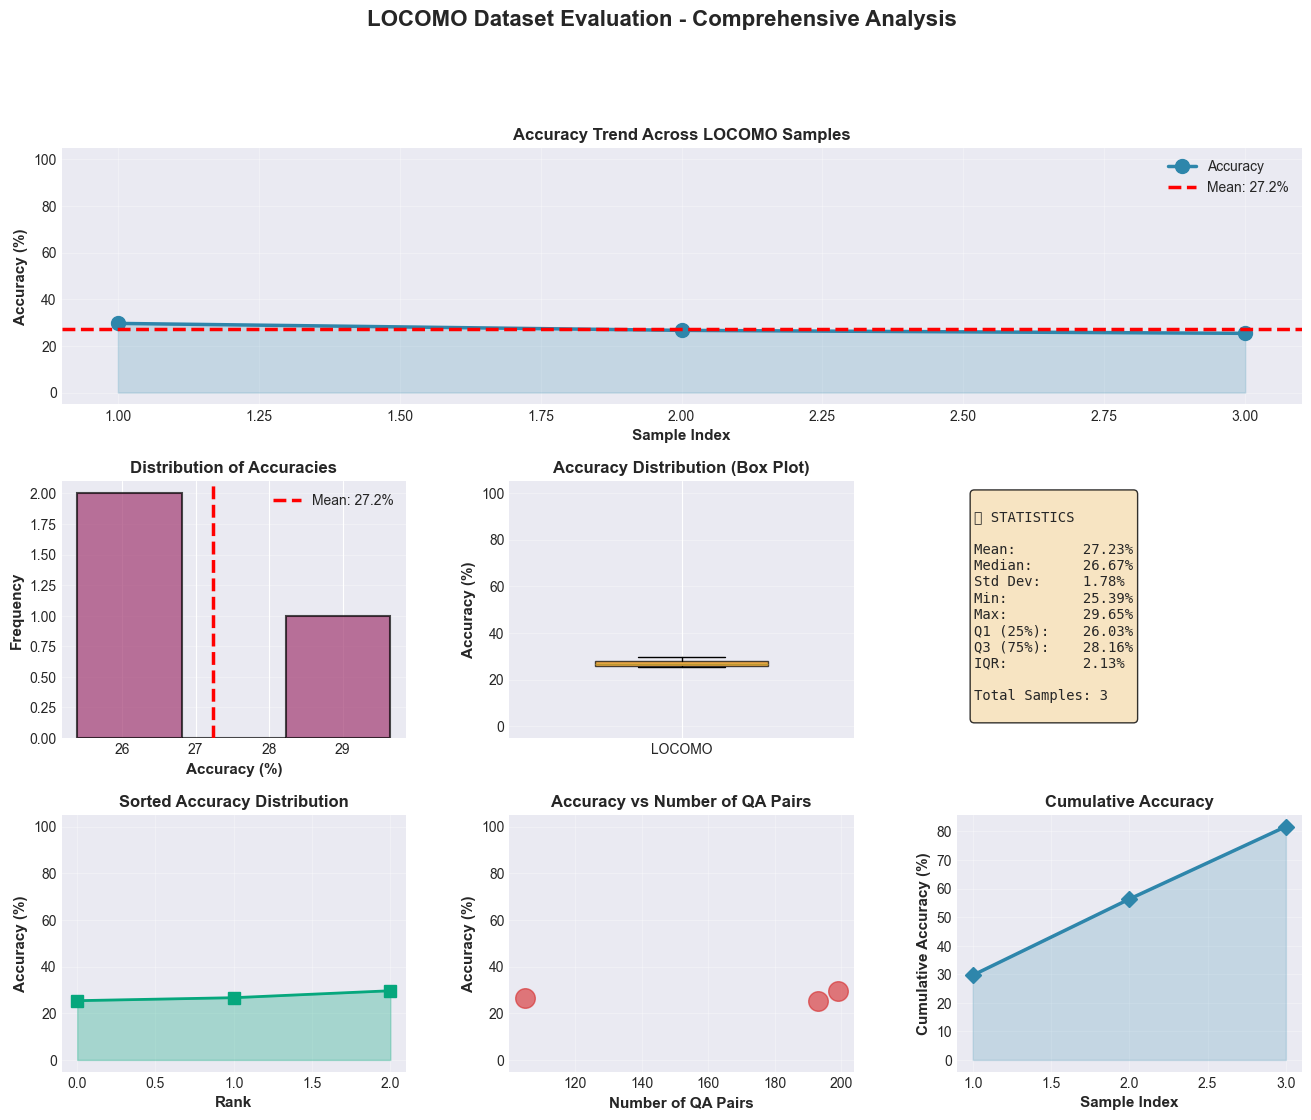

✅ Plots saved to: ./eval_results/locomo_evaluation_comprehensive.png


In [41]:
# Create output directory first
os.makedirs('./eval_results', exist_ok=True)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

fig.suptitle('LOCOMO Dataset Evaluation - Comprehensive Analysis', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. Line plot with mean
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(range(1, len(all_accuracies)+1), [a*100 for a in all_accuracies], 
         marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#2E86AB', label='Accuracy')
ax1.axhline(y=mean_accuracy*100, color='red', linestyle='--', linewidth=2.5, label=f'Mean: {mean_accuracy*100:.1f}%')
ax1.fill_between(range(1, len(all_accuracies)+1), [a*100 for a in all_accuracies], 
                  alpha=0.2, color='#2E86AB')
ax1.set_xlabel('Sample Index', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy Trend Across LOCOMO Samples', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10, loc='best')
ax1.set_ylim(-5, 105)

# 2. Histogram
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist([a*100 for a in all_accuracies], bins=max(3, len(all_accuracies)), 
         color='#A23B72', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axvline(x=mean_accuracy*100, color='red', linestyle='--', linewidth=2.5, label=f'Mean: {mean_accuracy*100:.1f}%')
ax2.set_xlabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Distribution of Accuracies', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Box plot
ax3 = fig.add_subplot(gs[1, 1])
bp = ax3.boxplot([a*100 for a in all_accuracies], vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#F18F01')
bp['boxes'][0].set_alpha(0.7)
ax3.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax3.set_title('Accuracy Distribution (Box Plot)', fontsize=12, fontweight='bold')
ax3.set_xticklabels(['LOCOMO'])
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(-5, 105)

# 4. Statistics text box
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')
stats_text = f"""
📊 STATISTICS

Mean:        {mean_accuracy*100:.2f}%
Median:      {median_accuracy*100:.2f}%
Std Dev:     {std_accuracy*100:.2f}%
Min:         {min_accuracy*100:.2f}%
Max:         {max_accuracy*100:.2f}%
Q1 (25%):    {q1*100:.2f}%
Q3 (75%):    {q3*100:.2f}%
IQR:         {(q3-q1)*100:.2f}%

Total Samples: {len(all_accuracies)}
"""
ax4.text(0.05, 0.95, stats_text, fontsize=10, verticalalignment='top',
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 5. Sorted accuracies
ax5 = fig.add_subplot(gs[2, 0])
sorted_acc = sorted([a*100 for a in all_accuracies])
ax5.plot(range(len(sorted_acc)), sorted_acc, marker='s', linestyle='-', 
         linewidth=2, markersize=8, color='#06A77D')
ax5.fill_between(range(len(sorted_acc)), sorted_acc, alpha=0.3, color='#06A77D')
ax5.set_xlabel('Rank', fontsize=11, fontweight='bold')
ax5.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax5.set_title('Sorted Accuracy Distribution', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.set_ylim(-5, 105)

# 6. Num QA vs Accuracy
ax6 = fig.add_subplot(gs[2, 1])
num_qa_list = [conversation_results[i]['num_qa'] for i in range(1, len(all_accuracies) + 1)]
ax6.scatter(num_qa_list, [a*100 for a in all_accuracies], s=200, alpha=0.6, color='#D62828')
ax6.set_xlabel('Number of QA Pairs', fontsize=11, fontweight='bold')
ax6.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax6.set_title('Accuracy vs Number of QA Pairs', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.set_ylim(-5, 105)

# 7. Cumulative accuracy
ax7 = fig.add_subplot(gs[2, 2])
cumsum = np.cumsum([a*100 for a in all_accuracies])
ax7.plot(range(1, len(cumsum)+1), cumsum, marker='D', linestyle='-', 
         linewidth=2.5, markersize=8, color='#2E86AB')
ax7.fill_between(range(1, len(cumsum)+1), cumsum, alpha=0.2, color='#2E86AB')
ax7.set_xlabel('Sample Index', fontsize=11, fontweight='bold')
ax7.set_ylabel('Cumulative Accuracy (%)', fontsize=11, fontweight='bold')
ax7.set_title('Cumulative Accuracy', fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./eval_results/locomo_evaluation_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plots saved to: ./eval_results/locomo_evaluation_comprehensive.png")

## 🔟 Save Results to JSON

In [42]:
# Create output directory
os.makedirs('./eval_results', exist_ok=True)

# Save comprehensive results
results_summary = {
    "timestamp": datetime.now().isoformat(),
    "configuration": {
        "llm_provider": "groq",
        "llm_model": "llama-3.1-8b-instant",
        "embedder_provider": "huggingface",
        "embedder_model": "sentence-transformers/all-mpnet-base-v2",
        "embedding_dims": 768,
        "vector_store": "qdrant",
    },
    "statistics": {
        "mean_accuracy": float(mean_accuracy),
        "median_accuracy": float(median_accuracy),
        "std_accuracy": float(std_accuracy),
        "min_accuracy": float(min_accuracy),
        "max_accuracy": float(max_accuracy),
        "q1": float(q1),
        "q3": float(q3),
    },
    "dataset": {
        "total_conversations": len(all_accuracies),
        "evaluation_time_seconds": elapsed,
    },
    "accuracies": [float(a) for a in all_accuracies],
    "per_conversation_results": conversation_results,
}

# Save JSON
with open('./eval_results/locomo_evaluation_results.json', 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)

# Save CSV
results_df.to_csv('./eval_results/locomo_evaluation_results.csv', index=False)

print("✅ Results saved:")
print("   - ./eval_results/locomo_evaluation_results.json")
print("   - ./eval_results/locomo_evaluation_results.csv")
print("   - ./eval_results/locomo_evaluation_comprehensive.png")

✅ Results saved:
   - ./eval_results/locomo_evaluation_results.json
   - ./eval_results/locomo_evaluation_results.csv
   - ./eval_results/locomo_evaluation_comprehensive.png


## 📝 Summary

In [43]:
print("\n" + "="*70)
print("✅ LOCOMO EVALUATION COMPLETE")
print("="*70)
print(f"\n🎯 Key Results:")
print(f"   • Mean Accuracy: {mean_accuracy*100:.2f}%")
print(f"   • Total Conversations: {len(all_accuracies)}")
print(f"   • Evaluation Time: {elapsed:.2f}s")
print(f"\n🔧 System Configuration:")
print(f"   • LLM: Groq - llama-3.1-8b-instant (Free)")
print(f"   • Embedder: HuggingFace - all-mpnet-base-v2 (768-dim)")
print(f"   • Vector Store: Qdrant (Local)")
print(f"   • Status: Completely FREE ✨")
print(f"\n📊 Outputs:")
print(f"   • JSON: ./eval_results/locomo_evaluation_results.json")
print(f"   • CSV: ./eval_results/locomo_evaluation_results.csv")
print(f"   • PNG: ./eval_results/locomo_evaluation_comprehensive.png")
print("\n" + "="*70)


✅ LOCOMO EVALUATION COMPLETE

🎯 Key Results:
   • Mean Accuracy: 27.23%
   • Total Conversations: 3
   • Evaluation Time: 2571.08s

🔧 System Configuration:
   • LLM: Groq - llama-3.1-8b-instant (Free)
   • Embedder: HuggingFace - all-mpnet-base-v2 (768-dim)
   • Vector Store: Qdrant (Local)
   • Status: Completely FREE ✨

📊 Outputs:
   • JSON: ./eval_results/locomo_evaluation_results.json
   • CSV: ./eval_results/locomo_evaluation_results.csv
   • PNG: ./eval_results/locomo_evaluation_comprehensive.png

